In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [3]:
# LOAD DATASET
df = pd.read_csv("../data/insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [5]:
# DATASET SHAPE
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1338
Columns: 7


In [6]:
# CHECK DATATYPES
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
# STATISTICAL SUMMARY
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.00,27.0000,39.00,51.000,64.00
bmi,1338.0,30.665471,6.098382,16.00,26.3000,30.40,34.700,53.10
children,1338.0,1.094918,1.205493,0.00,0.0000,1.00,2.000,5.00
expenses,1338.0,13270.422414,12110.011240,1121.87,4740.2875,9382.03,16639.915,63770.43


In [8]:
# MISSING VALUES
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [9]:
# DUPLICATE ROWS
df.duplicated().sum()

np.int64(1)

In [10]:
df = df.drop_duplicates()

In [11]:
# Separate Numerical & Categorical Columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = df.select_dtypes(include="object").columns

print(numerical_cols)
print(categorical_cols)

Index(['age', 'bmi', 'children', 'expenses'], dtype='str')
Index(['sex', 'smoker', 'region'], dtype='str')


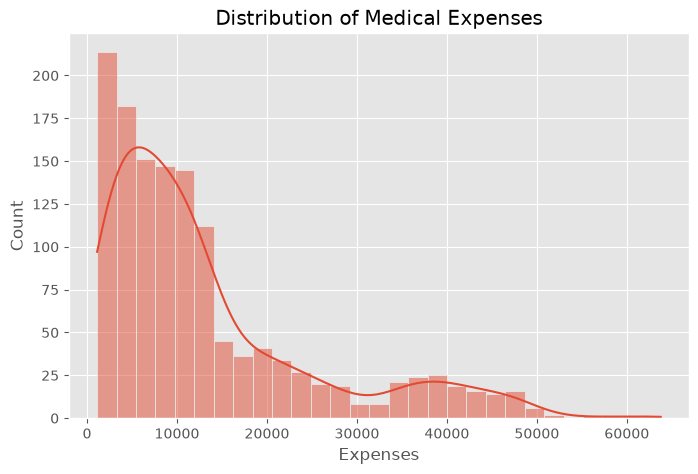

In [16]:
# Target Variable Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["expenses"], kde=True)

plt.title("Distribution of Medical Expenses")
plt.xlabel("Expenses")
plt.ylabel("Count")

plt.show()

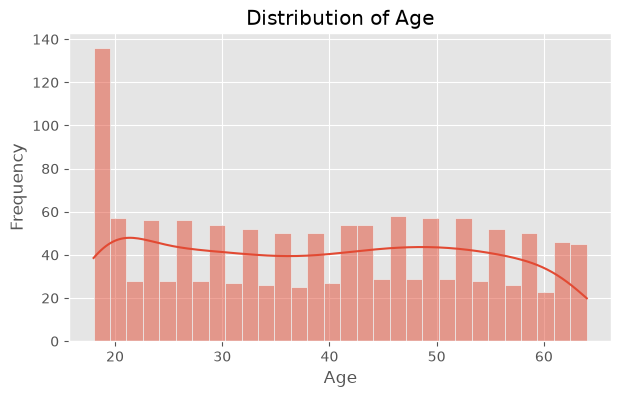

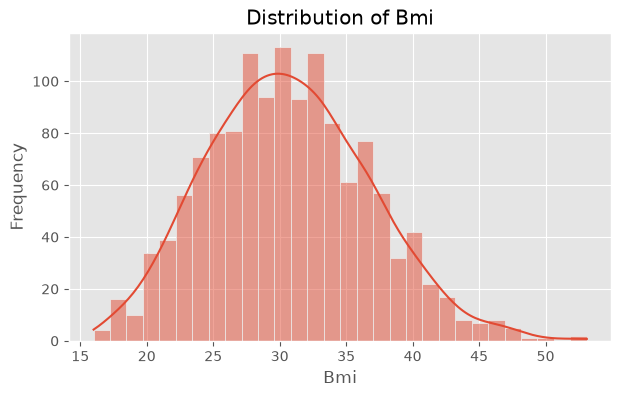

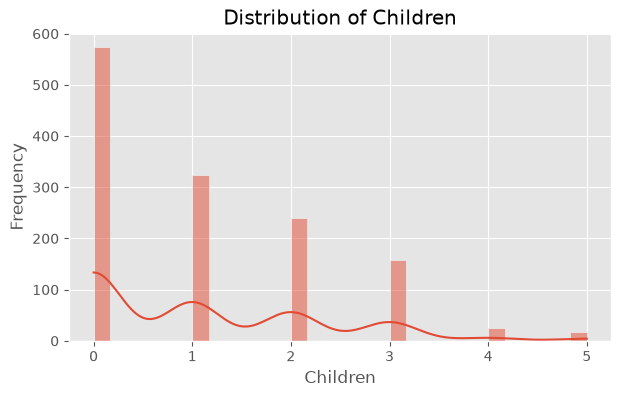

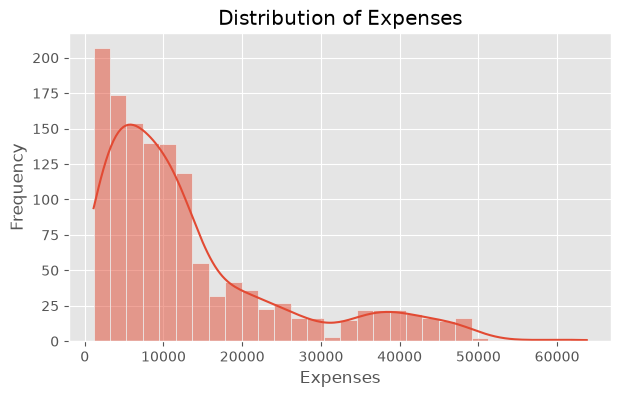

In [17]:
# Numerical Feature Distributions
numerical_cols = ["age", "bmi", "children", "expenses"]

for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(f"Distribution of {col.title()}")
    plt.xlabel(col.title())
    plt.ylabel("Frequency")

    plt.show()

## Numerical Feature Distribution Insights

- Age is approximately uniformly distributed.
- BMI follows an approximately normal distribution with a few outliers.
- Children is a discrete numerical variable, with most individuals having 0–2 children.
- Expenses are heavily right-skewed, suggesting a few individuals have significantly higher insurance costs.

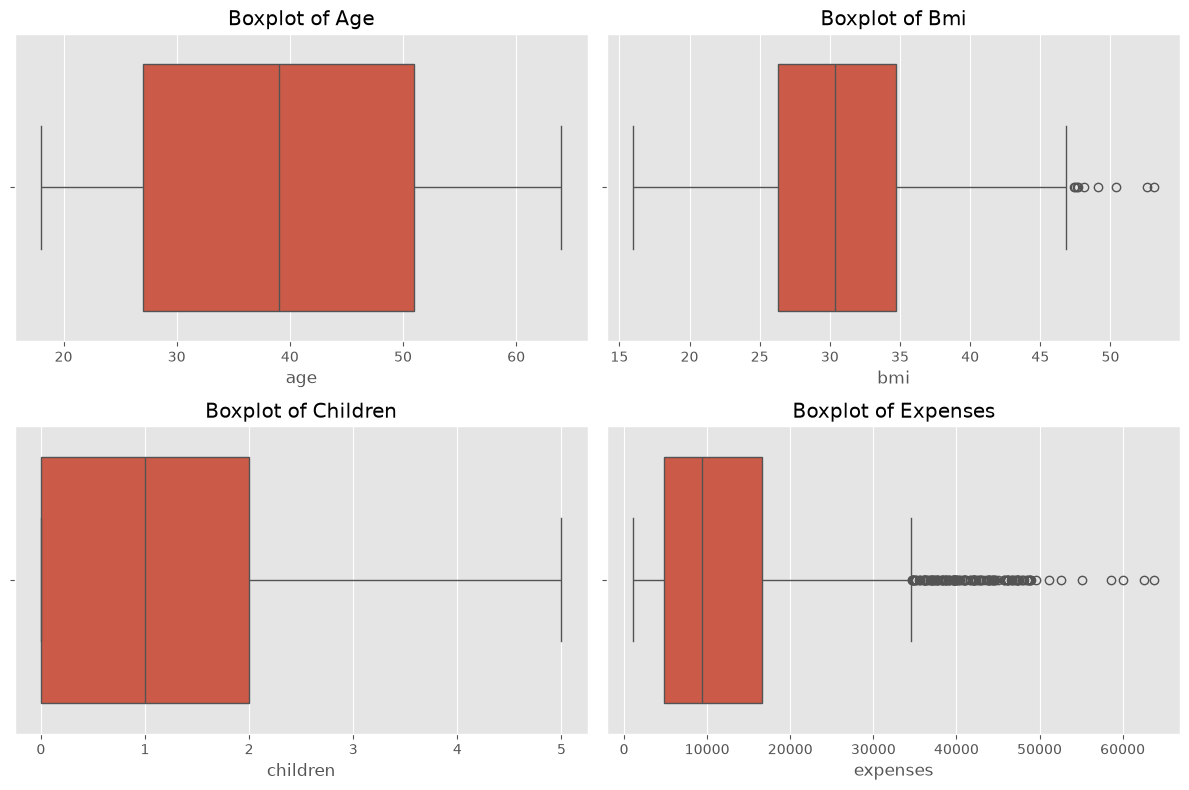

In [19]:
# Distribution by Boxplots (Better Outlier Detection)
plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols):

    plt.subplot(2,2,i+1)

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col.title()}")

plt.tight_layout()

plt.show()

## Outlier Analysis

- BMI contains a few high-value outliers.
- Expenses contain several high-value observations.
- These expense outliers likely represent genuine medical cases and will be retained.

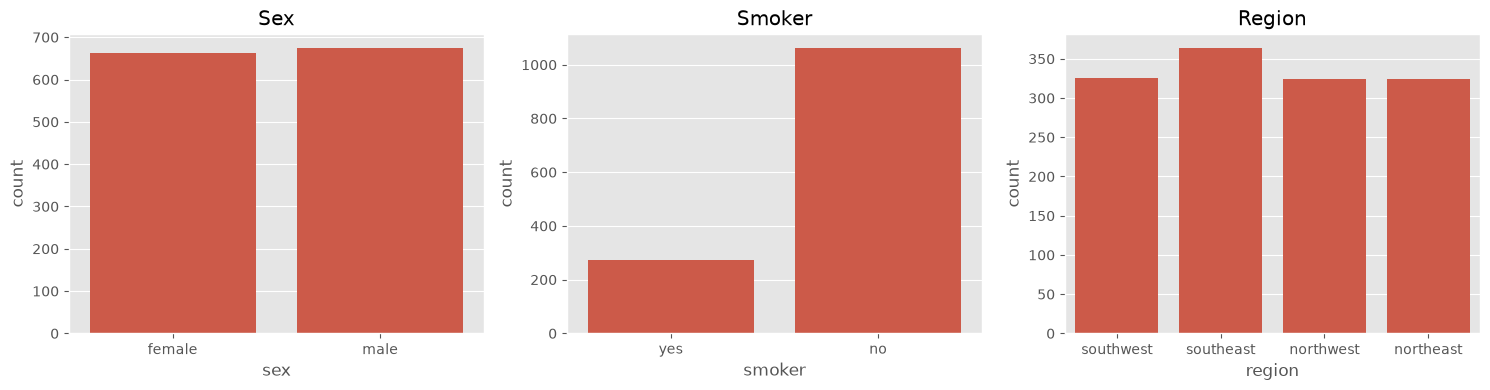

In [20]:
# Count Plots for Categorical Features
categorical_cols = ["sex", "smoker", "region"]

plt.figure(figsize=(15,4))

for i, col in enumerate(categorical_cols):

    plt.subplot(1,3,i+1)

    sns.countplot(data=df, x=col)

    plt.title(col.title())

plt.tight_layout()

plt.show()

## Categorical Feature Insights

- Male and female policyholders are nearly equally represented.
- Most individuals are non-smokers.
- The dataset is well distributed across all regions.

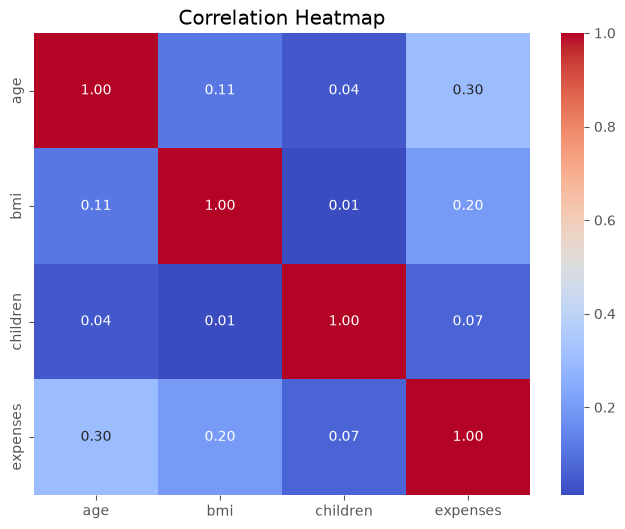

In [21]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

- Age has a positive relationship with medical expenses.
- BMI also shows a positive relationship with expenses.
- Children has only a weak correlation with expenses.

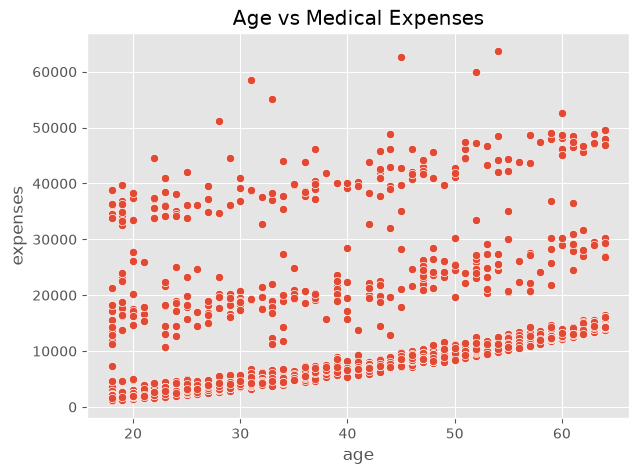

In [22]:
#Scatter Plots (Relationship with Target)
# Age VS Expenses
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="age",
    y="expenses"
)

plt.title("Age vs Medical Expenses")

plt.show()

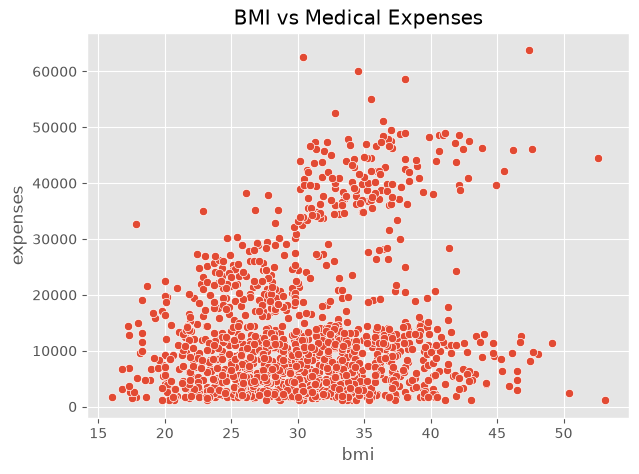

In [23]:
# BMI vs Expenses
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="expenses"
)

plt.title("BMI vs Medical Expenses")

plt.show()

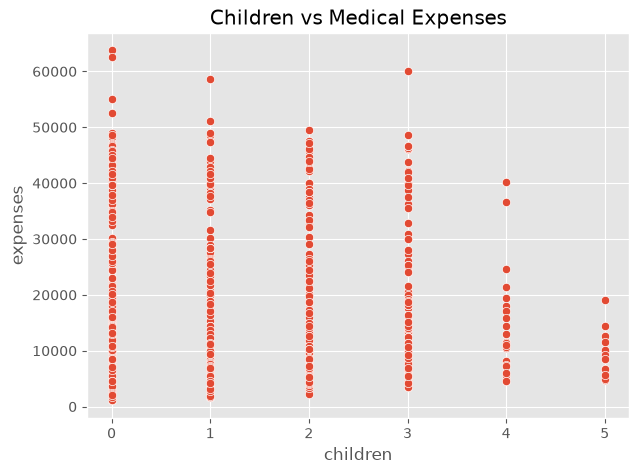

In [24]:
# Children VS Expenses
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="children",
    y="expenses"
)

plt.title("Children vs Medical Expenses")

plt.show()

## Scatter Plot Insights

- Medical expenses generally increase with age.
- Higher BMI values tend to be associated with higher expenses.
- The number of children has only a slight effect on expenses.

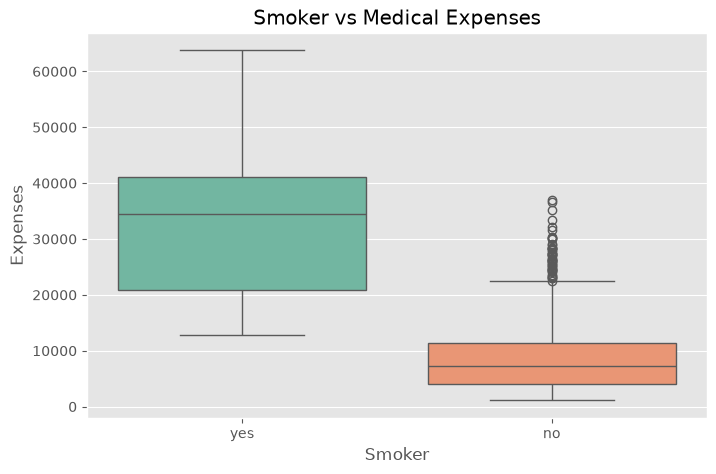

In [25]:
# Analyze Categorical Features vs Target (Expenses)
# Smoker VS Expenses
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="expenses",
    palette="Set2"
)

plt.title("Smoker vs Medical Expenses")
plt.xlabel("Smoker")
plt.ylabel("Expenses")

plt.show()

## Smoker vs Expenses

- Smokers incur significantly higher medical expenses than non-smokers.
- Smoking status appears to be one of the strongest predictors of insurance cost.

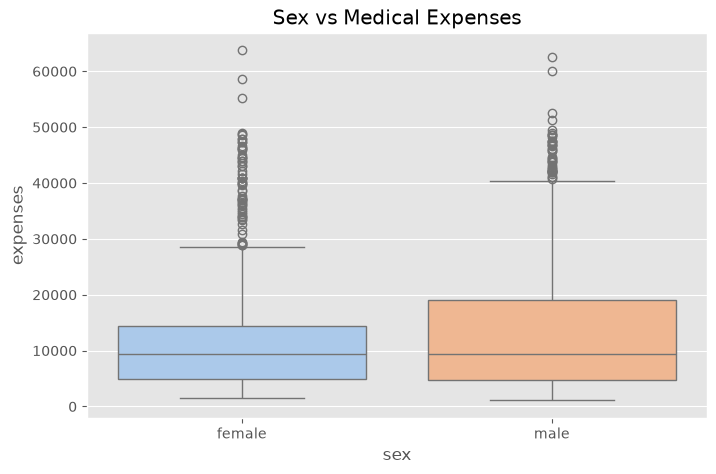

In [26]:
# Sex VS Expenses
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sex",
    y="expenses",
    palette="pastel"
)

plt.title("Sex vs Medical Expenses")

plt.show()

## Sex vs Expenses

- Medical expenses are relatively similar for males and females.
- Gender alone does not strongly influence insurance expenses.

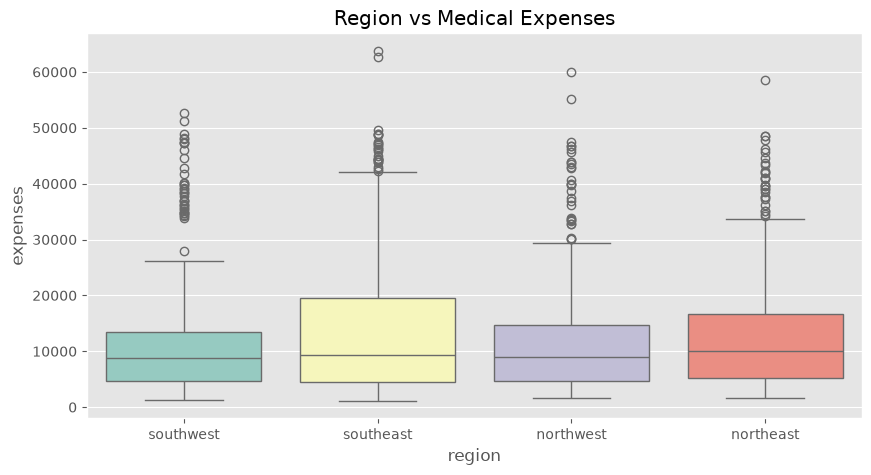

In [27]:
# Region VS Expenses
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="region",
    y="expenses",
    palette="Set3"
)

plt.title("Region vs Medical Expenses")

plt.show() 

## Region vs Expenses

- Medical expenses are relatively consistent across regions.
- Region is not a major determining factor of insurance cost.

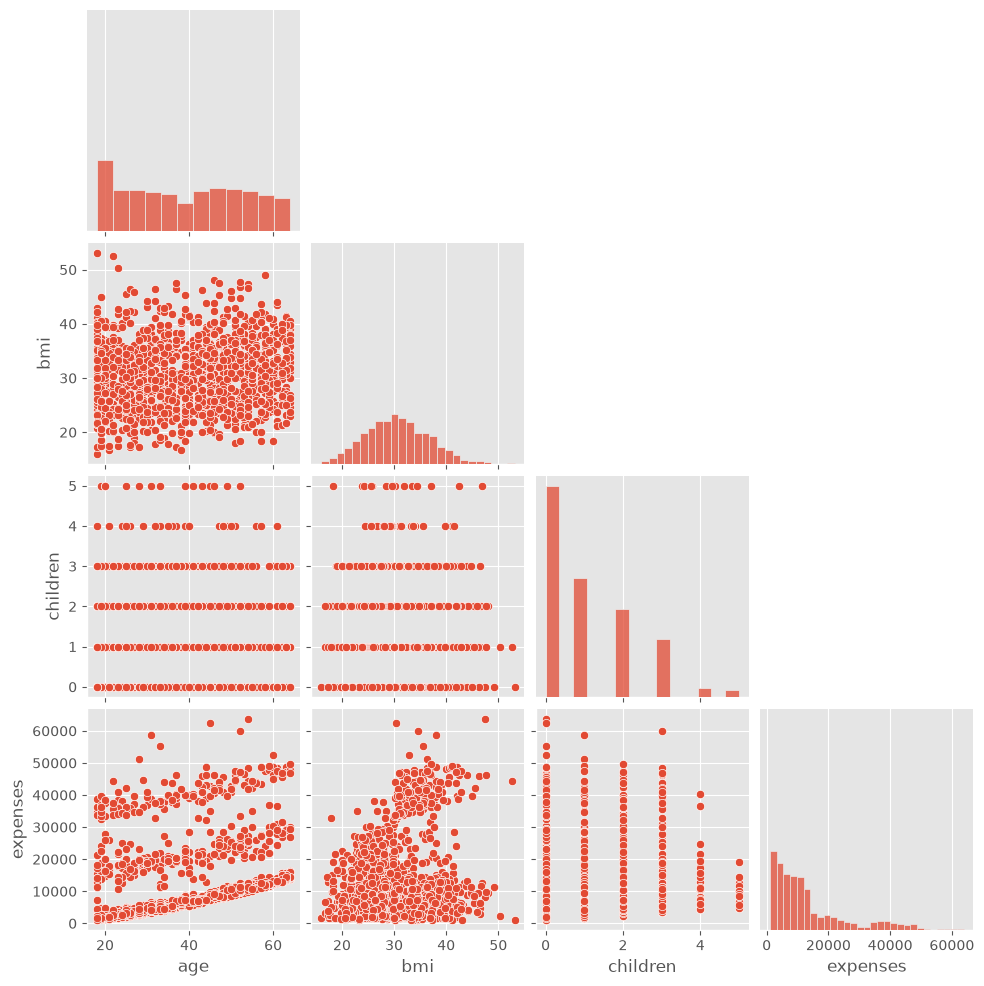

In [28]:
# Pairplot
sns.pairplot(
    df,
    corner=True
)

plt.show()

## Pairplot Observations

- Expenses tend to increase with age.
- BMI shows a moderate relationship with expenses.
- Children have a weak relationship with expenses.
- Expenses exhibit considerable variability.

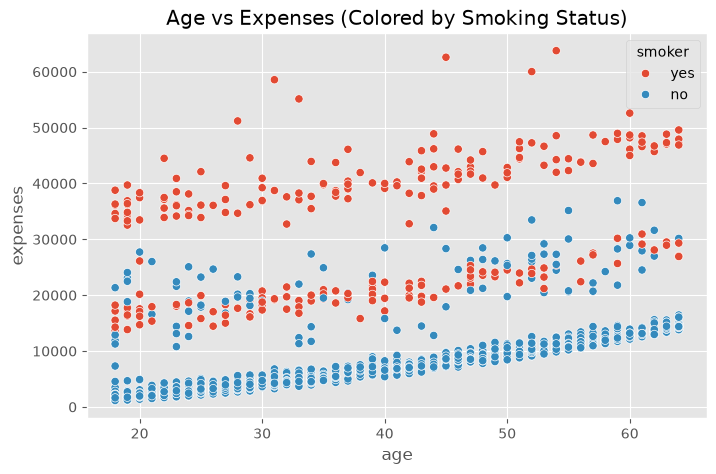

In [29]:
# Feature Relationships by Smoker
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="expenses",
    hue="smoker"
)

plt.title("Age vs Expenses (Colored by Smoking Status)")

plt.show()

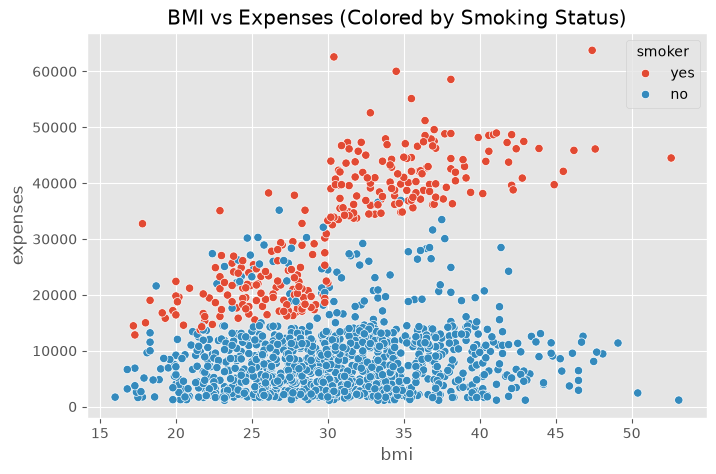

In [30]:
# BMI vs Expenses by Smoking Status
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="expenses",
    hue="smoker"
)

plt.title("BMI vs Expenses (Colored by Smoking Status)")

plt.show()

# Final EDA Summary
# Exploratory Data Analysis Summary

## Dataset Overview

- Total Records: 1338
- Total Features: 7
- Missing Values: None
- Duplicate Records: Checked and removed if any

## Numerical Features

- Age is approximately uniformly distributed.
- BMI is nearly normally distributed with a few outliers.
- Children is a discrete variable with most policyholders having 0–2 children.
- Expenses are heavily right-skewed.

## Categorical Features

- Male and female policyholders are nearly equally represented.
- Non-smokers significantly outnumber smokers.
- Regions are fairly balanced.

## Correlation

- Age has a positive correlation with expenses.
- BMI has a moderate positive correlation.
- Children has a weak correlation.

## Key Findings

- Smoking status is the strongest predictor of medical expenses.
- Older individuals generally have higher medical expenses.
- Higher BMI is associated with increased expenses.
- Region and sex have comparatively smaller effects.
- The dataset is clean and ready for preprocessing and model building.